In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

In [4]:
CLEAN_DIR = '../../data/clean/'

df_pop = pd.read_csv(f'{CLEAN_DIR}table3_uk_population_long.csv')
df_youth = pd.read_csv(f'{CLEAN_DIR}youth_unemployment_16_24_real.csv')

print(df_pop.shape, df_youth.shape)
df_pop.head(), df_youth.head()

(14580, 6) (68, 8)


(   Age      Sex  Population  Year      Age_Group           LFS_Age_Group
 0    0  Persons      667994  2024  0-17 Children  0-15 Below working age
 1    1  Persons      690113  2024  0-17 Children  0-15 Below working age
 2    2  Persons      732532  2024  0-17 Children  0-15 Below working age
 3    3  Persons      728400  2024  0-17 Children  0-15 Below working age
 4    4  Persons      755117  2024  0-17 Children  0-15 Below working age,
    Year Age_Group      Sex  Population  Unemployment_Rate_Pct  \
 0  1990     16-24  Females     3802284                     12   
 1  1990     16-24    Males     3913970                     14   
 2  1991     16-24  Females     3691253                     14   
 3  1991     16-24    Males     3799851                     17   
 4  1992     16-24  Females     3570934                     16   
 
    Unemployed_Count  Employed_Count                                   Source  
 0            448670         3353614  ONS Mid-Year Estimates + ONS LFS A05 SA

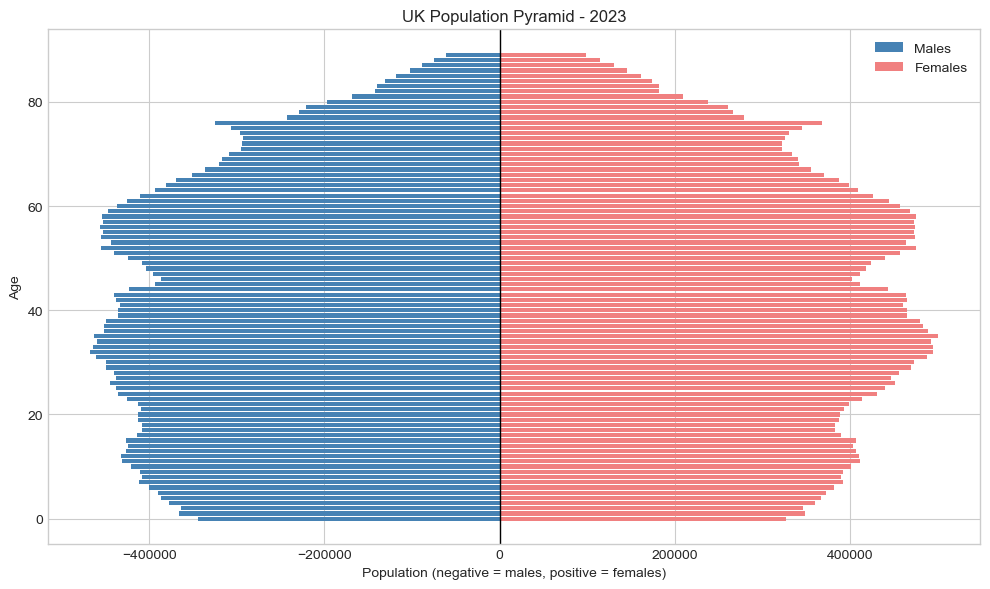

In [11]:
year = 2023 # change to 1990, 2000, 2004 etc

df_year = df_pop[
    (df_pop['Year'] == year) & 
    (df_pop['Sex'].isin(['Males', 'Females']))
    ]

plt.figure(figsize=(10, 6))

males = df_year[df_year['Sex'] == 'Males'].copy()
females = df_year[df_year['Sex'] == 'Females'].copy()

plt.barh(males['Age'], -males['Population'], color='steelblue', label='Males')
plt.barh(females['Age'], females['Population'], color='lightcoral', label='Females')

plt.axvline(0, color='black', linewidth=1)
plt.title(f"UK Population Pyramid - {year}")
plt.xlabel("Population (negative = males, positive = females)")
plt.ylabel("Age")
plt.legend()
plt.tight_layout()
plt.show()

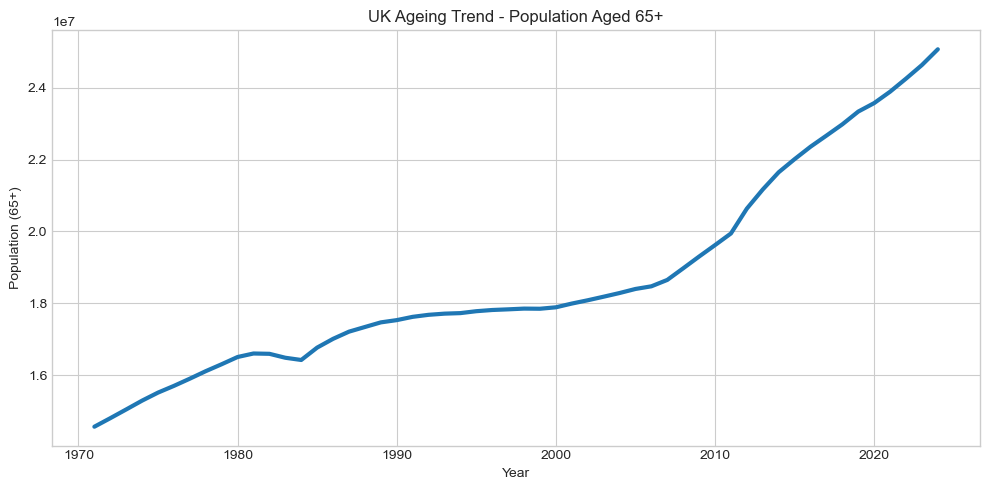

In [14]:
ageing = (
    df_pop[df_pop['Age'] >= 65]
    .groupby('Year')['Population']
             .sum()
             .reset_index()
            )

plt.figure(figsize=(10, 5))
plt.plot(ageing['Year'], ageing['Population'], linewidth=3)
plt.title("UK Ageing Trend - Population Aged 65+")
plt.xlabel("Year")
plt.ylabel("Population (65+)")
plt.grid(True)
plt.tight_layout()
plt.show()

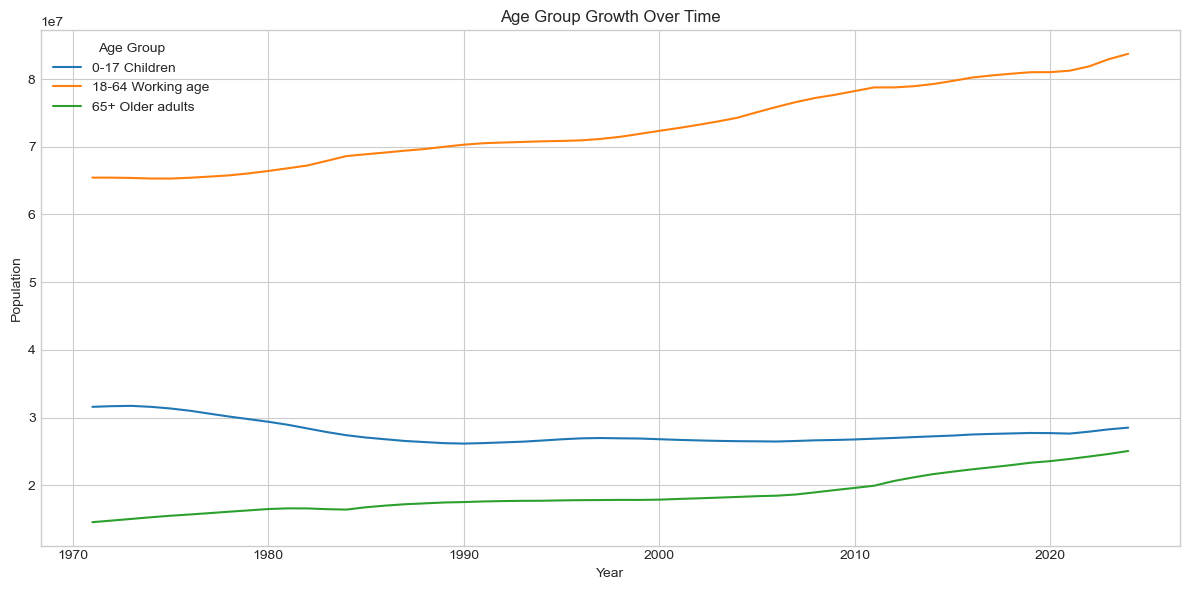

In [19]:
age_groups = (
    df_pop.groupby(['Year', 'Age_Group'])['Population']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for grp in sorted(age_groups['Age_Group'].unique()):
    subset = age_groups[age_groups['Age_Group'] == grp]
    plt.plot(subset['Year'], subset['Population'], label=grp)

plt.title("Age Group Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

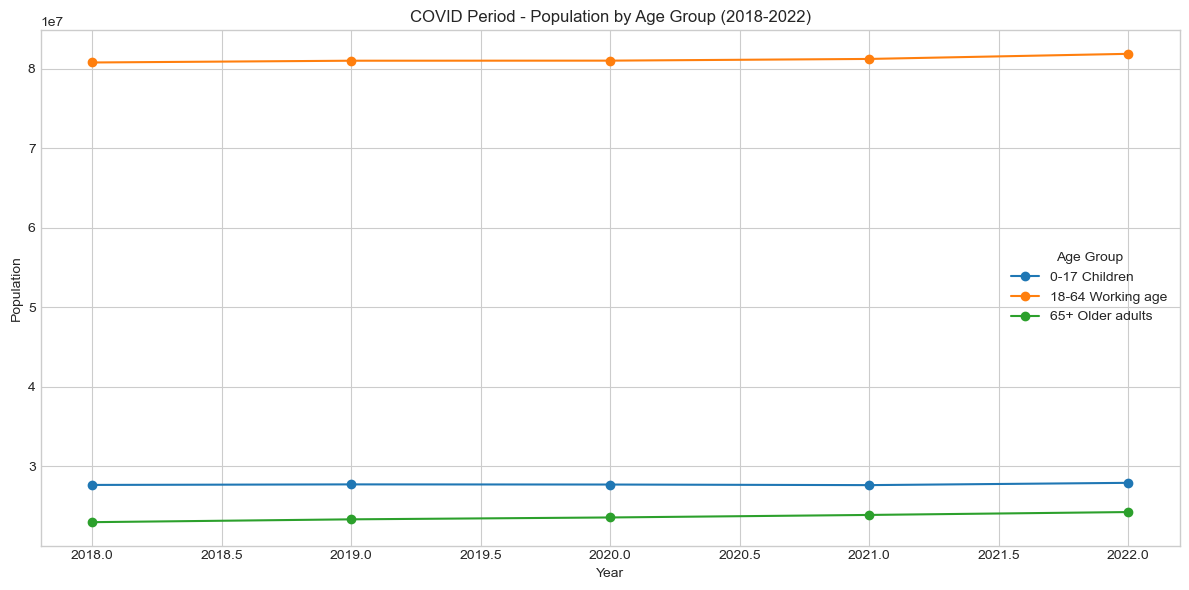

In [22]:
covid = df_pop[df_pop['Year'].between(2018, 2022)]
covid_grp = (
    covid.groupby(['Year', 'Age_Group'])['Population']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
for grp in sorted(covid_grp['Age_Group'].unique()):
    subset = covid_grp[covid_grp['Age_Group'] == grp]
    plt.plot(subset['Year'], subset['Population'], marker='o', label=grp)

plt.title("COVID Period - Population by Age Group (2018-2022)")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend(title="Age Group")
plt.tight_layout()
plt.show()

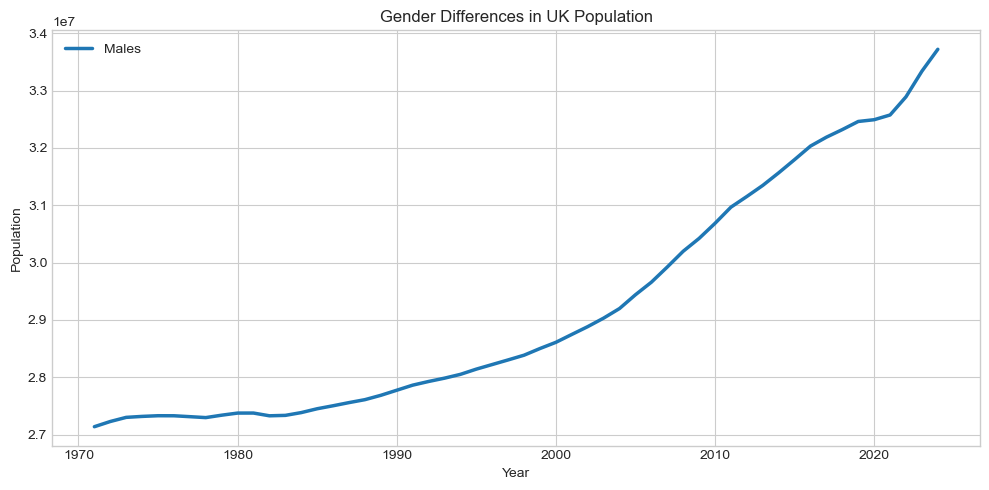

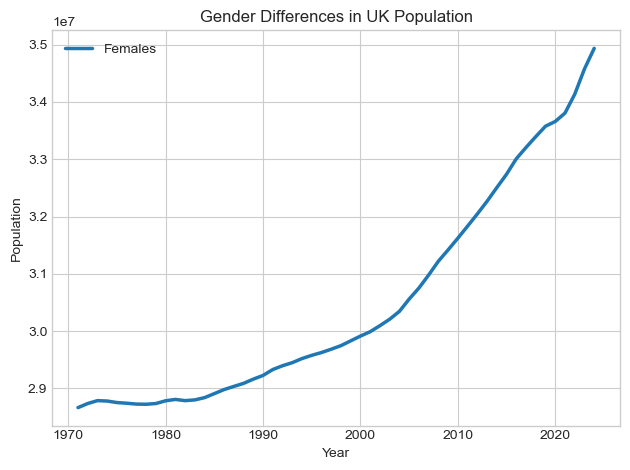

In [23]:
sex_trend = (
    df_pop.groupby(['Year', 'Sex'])['Population']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
for sex in ['Males', 'Females']:
    subset = sex_trend[sex_trend['Sex'] == sex]
    plt.plot(subset['Year'], subset['Population'], label=sex, linewidth=2.5)

    plt.title("Gender Differences in UK Population")
    plt.xlabel("Year")
    plt.ylabel("Population")
    plt.legend()
    plt.tight_layout()
    plt.show()

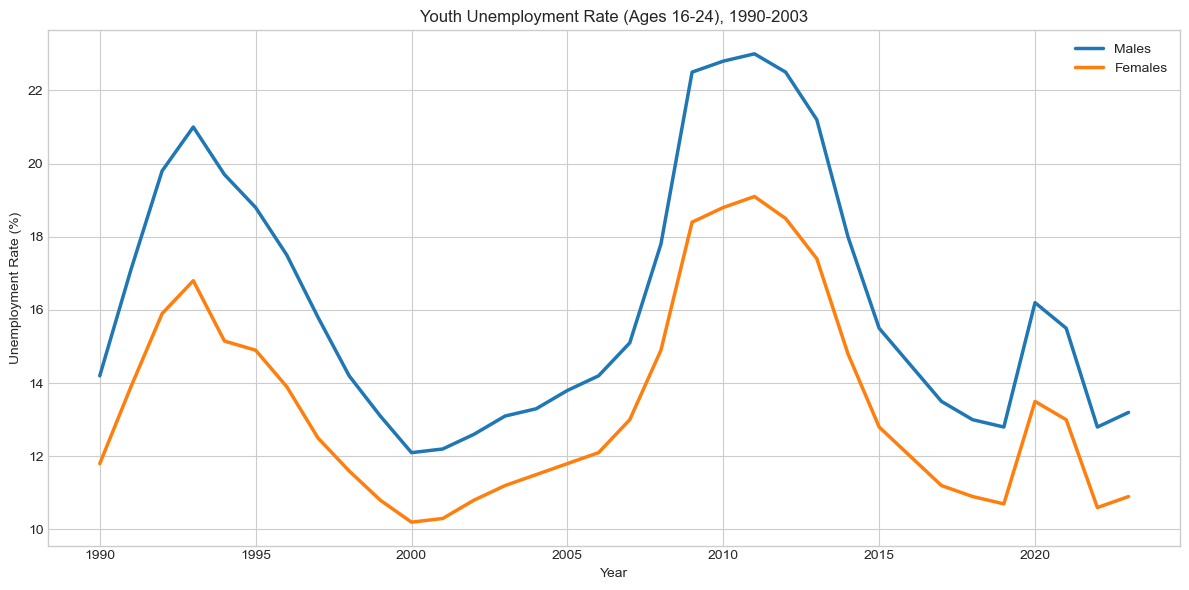

In [24]:
plt.figure(figsize=(12, 6))
for sex in ['Males', 'Females']:
    subset = df_youth[df_youth['Sex'] == sex]
    plt.plot(subset['Year'], subset['Unemployment_Rate_Pct'],
    label=sex, linewidth=2.5)

plt.title("Youth Unemployment Rate (Ages 16-24), 1990-2003")
plt.xlabel("Year")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

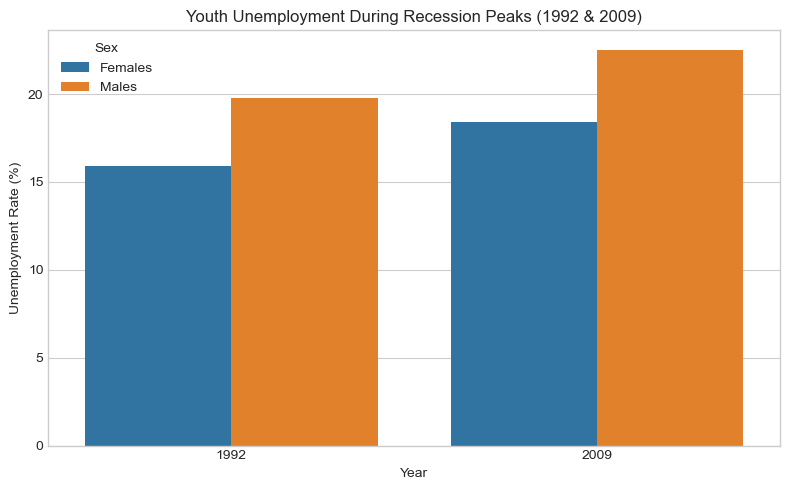

In [25]:
recession_years = df_youth[df_youth['Year'].isin([1992, 2009])]

plt.figure(figsize=(8, 5))
sns.barplot(data=recession_years,
            x='Year', y='Unemployment_Rate_Pct', hue='Sex')
plt.title("Youth Unemployment During Recession Peaks (1992 & 2009)")
plt.ylabel("Unemployment Rate (%)")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

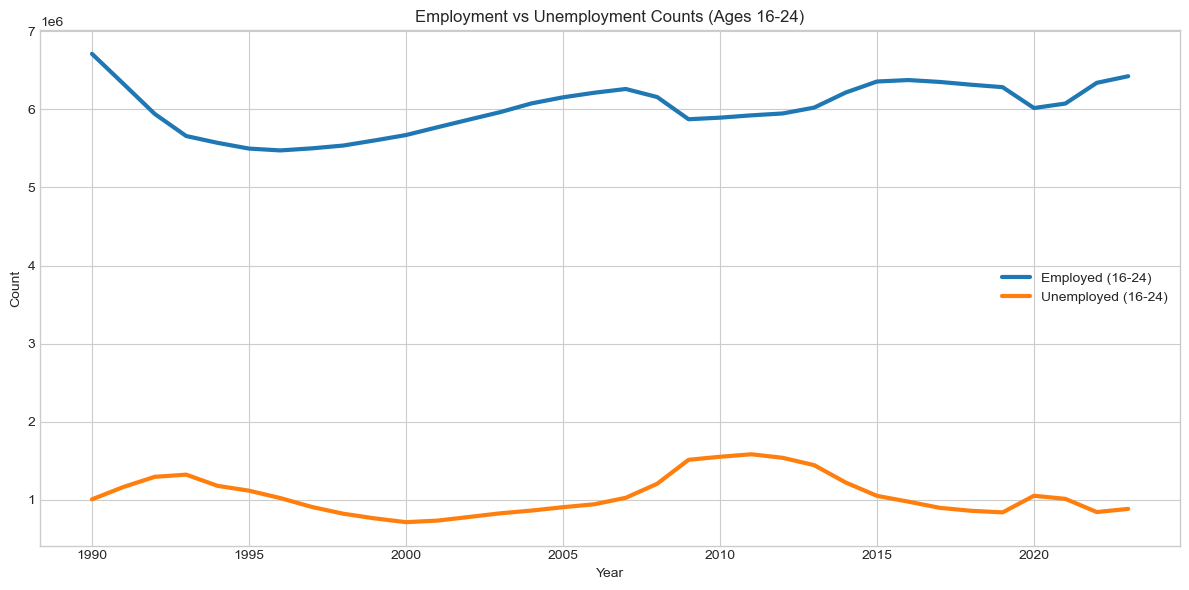

In [26]:
totals = (
    df_youth.groupby('Year')[['Employed_Count', 'Unemployed_Count']]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(totals['Year'], totals['Employed_Count'],
         label='Employed (16-24)', linewidth=3)
plt.plot(totals['Year'], totals['Unemployed_Count'],
         label='Unemployed (16-24)', linewidth=3)

plt.title("Employment vs Unemployment Counts (Ages 16-24)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show

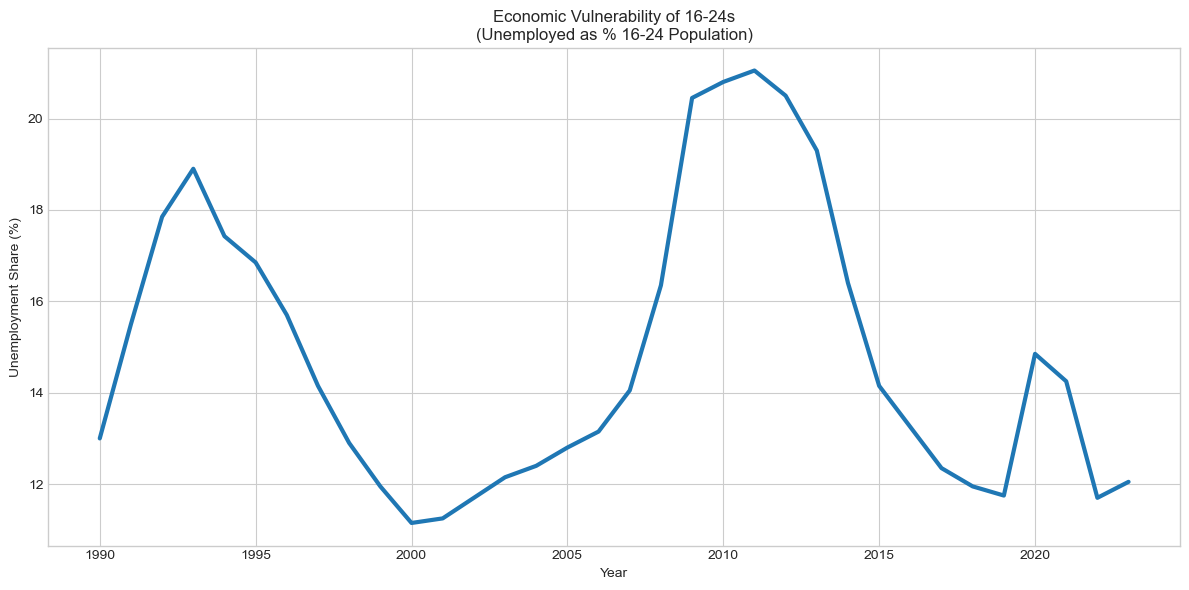

In [28]:
df_youth['Unemployment_Share_Pct'] = (
    df_youth['Unemployed_Count'] / df_youth['Population'] * 100
)

share = (
    df_youth.groupby('Year')['Unemployment_Share_Pct']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))
plt.plot(share['Year'], share['Unemployment_Share_Pct'], linewidth=3)
plt.title("Economic Vulnerability of 16-24s\n(Unemployed as % 16-24 Population)")
plt.xlabel("Year")
plt.ylabel("Unemployment Share (%)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary of this Notebook 

## 1. Population Pyramid 

- the shape of the population
- gender differences at older ages

## 2. Ageing Trend (65+)

- clear and steady rise in the older generation
- acceleration in ageing from the 200s onward
- long term demographic pressure on health, pensions and social care

## 3. Age Group Over Time

- which age groups are expanding and shrinking
- generational shifts over time

## 4. Covid-19 Impact

- disruptions in population growth
- changes in migration patterns

## 5. Gender Differences in Total Population

- a consistent female majority
- long term stability in gender proprtions

## 6. Youth Unemployment Rate 

- recession peaks in 1992 and 2009
- COVID spike in 2020

## 7. Recession Peaks (1992 & 2009)

- sharp increase in youth unemployment during downturns
- males consistently experiencing higher unemployment than females
- the severity of the 2009 recession compared to 1992

## 8. Employment vs Unemployment Counts 

- long term employment recovery after recessions
- the scale of unemployment relative to the total youth population

## 9 Economic Vulnerability of 16-24s

- the share of young people directly affected by unemployment
- periods of heightened vulnerability (1990, 2009, 2020)

# Notebook Complete
## All Analysis is complete